# From 0-D to 1-D: Introduction to `sympl` and `climt`
---

## The Story So Far
In our previous notebooks, we used **`xarray`** to analyze satellite data (like CERES) and built a **Zero-Dimensional (0-D) Energy Balance Model**. While our 0-D model helped us understand global feedback loops (like ice-albedo), it treated the entire Earth as a single, uniform dot.

However the greenhouse effect requires us to stack atmospheric "shells". The continuous **Schwarzschild Equation** tracks how radiation changes as it interacts with the mass of the gas over a vertical column.

To build a computational model that simulates these 1-D vertical columns (and eventually full 3-D atmospheres), we can no longer rely on raw Python arrays.

1. **`sympl` (System for Modelling Planets):** It handles physical units, constants, and the execution.
2. **`climt` (Climate Modelling Toolkit):** It provides the actual scientific components (like Radiative Transfer and Boundary Layer physics) built on top of `sympl`.

In [1]:
import sympl
import climt
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

## The Importance of Units (`sympl.DataArray`)
---
Adding 273.15 to a temperature array is a common, but dangerous way to convert Celsius to Kelvin. What if the array was actually in Fahrenheit? `numpy` doesn't know, and it will silently compute the wrong answer.

`sympl` extends the `xarray.DataArray` we already know by strictly enforcing **unit awareness**.

In [2]:
# Raw numpy array representing temperatures
raw_temp = np.array([15.0, 20.0, 25.0])

# Now we wrap it in a sympl DataArray and declare its units
labeled_temp = sympl.DataArray(
    raw_temp,
    dims=['latitude'],
    attrs={'units': 'degC'}  # degC represents Celsius
)

print("Original:", labeled_temp.values, labeled_temp.attrs['units'])

Original: [15. 20. 25.] degC


In [3]:
# We can safely and automatically convert units
temp_kelvin = labeled_temp.to_units('degK')
print("Converted to Kelvin:", temp_kelvin)

Converted to Kelvin: <xarray.DataArray (latitude: 3)> Size: 24B
array([288.15, 293.15, 298.15])
Dimensions without coordinates: latitude
Attributes:
    units:    degK


If you try to convert an array that does not have an explicitly defined `units` attribute, `sympl` will crash. This is a **feature, not a bug**

## Discretizing the Atmosphere (`climt` Model State)
---
To run physical components, we need an "Atmosphere" to run them on. `climt` stores all physical quantities in a dictionary called the **Model State**.

Let's initialize a radiative transfer component and ask `climt` to generate a default 1-D vertical column for it.

In [4]:
# Initialize a Longwave Radiation component
rad_lw = climt.GrayLongwaveRadiation()

# Generate a default model state (a 1-D vertical column) required for this component
model_state = climt.get_default_state([rad_lw])

# Let's look at the keys (variables) generated
print(list(model_state.keys()))

['atmosphere_hybrid_sigma_pressure_a_coordinate_on_interface_levels', 'atmosphere_hybrid_sigma_pressure_b_coordinate_on_interface_levels', 'surface_air_pressure', 'time', 'air_pressure', 'air_pressure_on_interface_levels', 'longitude', 'latitude', 'height_on_ice_interface_levels', 'longwave_optical_depth_on_interface_levels', 'air_temperature', 'surface_temperature']


### Interrogating Components and Modifying State
How did `climt` know to generate these specific variables? Every `sympl` component clearly defines its required inputs, outputs (tendencies or diagnostics), and their expected units. We can interrogate the component directly:

In [5]:
print("The Radiation Component strictly requires these inputs:")
for req_input in rad_lw.input_properties.keys():
    print(f" - {req_input}")

# Because model_state is just a dictionary of sympl.DataArrays, we can modify
# any of these initialized values using standard numpy indexing!

print("Original Surface Pressure (Pa):", model_state['surface_air_pressure'].values[0, 0])

# Let's change the surface pressure to simulate a high-pressure system (1050 hPa)
model_state['surface_air_pressure'].values[:] = 105000.0

print("Modified Surface Pressure (Pa):", model_state['surface_air_pressure'].values[0, 0])
# Note: Changing the 2D surface pressure scalar doesn't automatically re-calculate the
# 3D vertical pressure profile. We will look at vertical profiles next!

The Radiation Component strictly requires these inputs:
 - longwave_optical_depth_on_interface_levels
 - air_temperature
 - surface_temperature
 - air_pressure
 - air_pressure_on_interface_levels
Original Surface Pressure (Pa): 101320.0
Modified Surface Pressure (Pa): 105000.0


### The Schwarzschild Equation

The change in optical depth as proportional to the mass of the gas slice: $d\tau = k_\lambda \rho dz$.

To calculate the mass of a layer computationally, we use Hydrostatic Balance ($dp = -\rho g dz$). Therefore, the mass of a grid box is simply $\frac{\Delta p}{g}$.

Notice that `climt` generated two different pressure arrays:
1. `air_pressure`: The pressure in the **middle** of the layer ($p_m$). Temperature is defined here.
2. `air_pressure_on_interface_levels`: The pressure at the **top and bottom boundaries** of the layer ($p_i$).

Let's use `sympl` constants to calculate the mass of each layer using the interface levels!

In [6]:
# Fetch gravity safely using sympl 
g = sympl.get_constant('gravitational_acceleration', 'm/s^2')
model_state = climt.get_default_state([rad_lw])

# Calculate the pressure difference (dp) across each vertical layer.
# We subtract the top interface from the bottom interface for each layer.
p_interface = model_state['air_pressure_on_interface_levels'].to_units('pascal')
dp = p_interface[:-1] - p_interface[1:]

# Because we took the difference between boundaries, dp is now a "mid_level" quantity!
dp = dp.rename({'interface_levels': 'mid_levels'})

# Mass of the layer = dp / g
layer_mass = dp / g
layer_mass.attrs['units'] = 'kg/m^2'

print("Mass of the bottom 3 atmospheric layers (kg/m^2):\n", layer_mass.values[:3])

Mass of the bottom 3 atmospheric layers (kg/m^2):
 [[[ 56.20680342]]

 [[116.78475184]]

 [[175.97787792]]]


### Integrating the Column: Total Atmospheric Mass
Now that we have the mass of each individual layer (`layer_mass`), we can answer a fundamental question: **What is the total mass of the atmospheric column?**

Just like in our mathematical derivation, we integrate (sum) the mass over the vertical dimension (`mid_levels`).

In [7]:
total_column_mass = layer_mass.sum(dim='mid_levels')

print("Total Atmospheric Column Mass (kg/m^2): ", total_column_mass.values)

# Does this make physical sense?
# The default 1D column generated by climt starts with a standard 100,000 Pa surface pressure profile.
# Mass = P / g = 100,000 / 9.80665
expected_mass = model_state['surface_air_pressure'].values[0, 0] / g
print(f"Expected mass from P/g is {expected_mass:.1f} kg/m^2.")

Total Atmospheric Column Mass (kg/m^2):  [[10329.72523747]]
Expected mass from P/g is 10331.8 kg/m^2.


## Radiative Fluxes and Energy Conservation
---
The Top of Atmosphere (TOA) and Surface energy balances dictate the climate. The change in radiative flux across the column must equal the physical heating of the gas (First Law of Thermodynamics).

Let's run our `GrayLongwaveRadiation` component **once** to calculate the instantaneous fluxes ($I^+$ and $I^-$) and heating tendencies ($\frac{dT}{dt}$), and prove that energy is conserved.

In [8]:
# Run the component to get Tendencies (rates of change) and Diagnostics (static fluxes)
tendencies, diagnostics = rad_lw(model_state)

# Extract Upwelling (I+) and Downwelling (I-) fluxes
# We use squeeze() to remove the trivial latitude/longitude dimensions and just get the 1D vertical profile
lw_up = diagnostics['upwelling_longwave_flux_in_air'].values.squeeze()
lw_down = diagnostics['downwelling_longwave_flux_in_air'].values.squeeze()

# In climt, index 0 is the Surface, and index -1 is the Top of Atmosphere (TOA)
olr = lw_up[-1]
back_rad = lw_down[0]

print(f"Outgoing Longwave Radiation (OLR at TOA): {olr:.2f} W/m^2")
print(f"Back Radiation (Downwelling at Surface): {back_rad:.2f} W/m^2")

# Calculate Net Energy Added to the Column (Boundary Fluxes)
# Energy enters the column from the surface, and leaves from the TOA
net_flux_surface = lw_up[0] - lw_down[0] # Net flux leaving surface (entering bottom of atmosphere)
net_flux_toa = lw_up[-1] - lw_down[-1] # Net flux leaving TOA (exiting top of atmosphere)

net_energy_added = net_flux_surface - net_flux_toa
print(f"Net Energy Added to Column: {net_energy_added:.2f} W/m^2")

# Calculate the Vertical Integral of Heating Tendencies
# Integral = Sum( cp * (dT/dt) * mass )
cp = sympl.get_constant('heat_capacity_of_dry_air_at_constant_pressure', 'J/kg/K')
heating_rate = tendencies['air_temperature'].values.squeeze() # K/s
mass = layer_mass.values.squeeze() # kg/m^2

integrated_heating = np.sum(cp * heating_rate * mass)
print(f"Vertical Integral of Heating Rates: {integrated_heating:.2f} W/m^2")

# The difference should be effectively zero
print(f"\nEnergy Conservation Error: {abs(net_energy_added - integrated_heating):.2e} W/m^2")

Outgoing Longwave Radiation (OLR at TOA): 422.49 W/m^2
Back Radiation (Downwelling at Surface): 253.49 W/m^2
Net Energy Added to Column: -216.67 W/m^2
Vertical Integral of Heating Rates: -216.67 W/m^2

Energy Conservation Error: 7.97e-06 W/m^2


### Visualizing the Radiating Height
Space "sees" down into the atmosphere to an optical depth of roughly $\tau_{space} = 1$.

Let's plot the Longwave fluxes against the optical depth to visually see where the Upwelling radiation (OLR) originates.

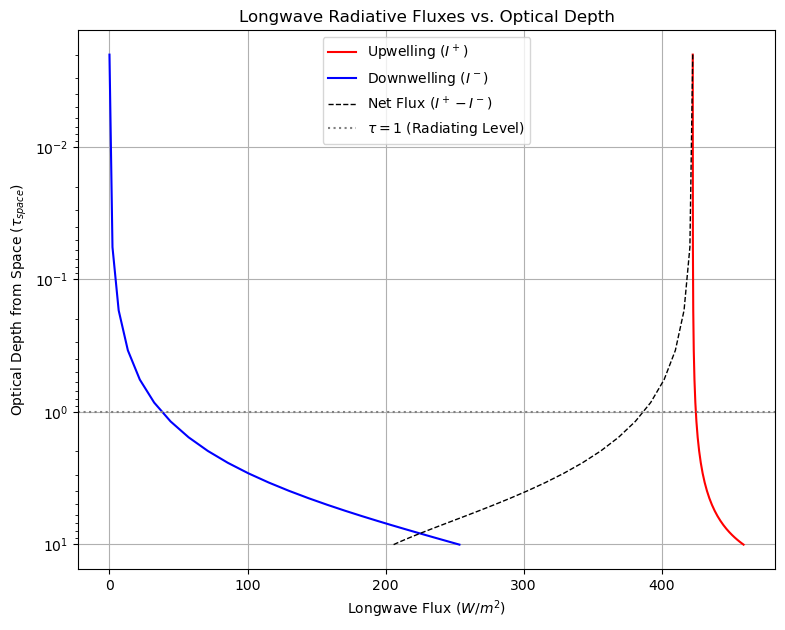

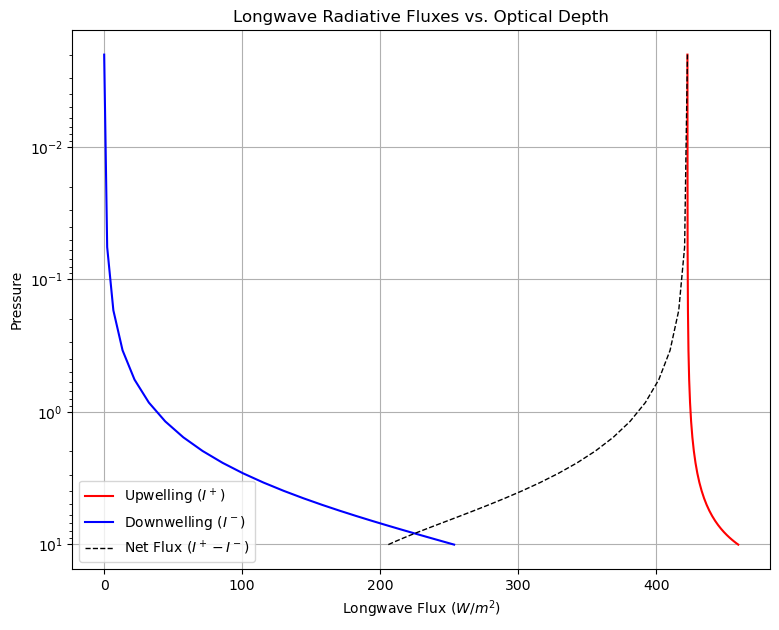

In [10]:
# Extract Optical Depth (tau)
pressure = model_state['air_pressure_on_interface_levels'].to_units('pascal').values.squeeze() / 10000.0

if 'longwave_optical_depth_on_interface_levels' in diagnostics:
    tau = diagnostics['longwave_optical_depth_on_interface_levels'].values.squeeze()
else:
    tau = pressure

plt.figure(figsize=(9, 7))

# Plot the fluxes
plt.plot(lw_up, tau, label='Upwelling ($I^+$)', color='red')
plt.plot(lw_down, tau, label='Downwelling ($I^-$)', color='blue')
plt.plot(lw_up - lw_down, tau, label='Net Flux ($I^+ - I^-$)', color='black', linestyle='--', linewidth=1)

# Invert Y-axis so TOA (tau=0) is at the top of the graph
plt.gca().invert_yaxis()

# Add a reference line for tau = 1 (The theoretical Radiating Height)
plt.axhline(1.0, color='gray', linestyle=':', label=r'$\tau = 1$ (Radiating Level)')

plt.yscale('log')
plt.xlabel('Longwave Flux ($W/m^2$)')
plt.ylabel(r'Optical Depth from Space ($\tau_{space}$)')
plt.title('Longwave Radiative Fluxes vs. Optical Depth')
plt.legend()
plt.grid(True)

plt.figure(figsize=(9, 7))

# Plot the fluxes
plt.plot(lw_up, pressure, label='Upwelling ($I^+$)', color='red')
plt.plot(lw_down, pressure, label='Downwelling ($I^-$)', color='blue')
plt.plot(lw_up - lw_down, pressure, label='Net Flux ($I^+ - I^-$)', color='black', linestyle='--', linewidth=1)

# Invert Y-axis so TOA (tau=0) is at the top of the graph
plt.gca().invert_yaxis()

plt.yscale('log')
plt.xlabel('Longwave Flux ($W/m^2$)')
plt.ylabel('Pressure')
plt.title('Longwave Radiative Fluxes vs. Optical Depth')
plt.legend()
plt.grid(True)

plt.show()

### Interpretation
* **Upwelling ($I^+$):** Notice how it steadily grows from the surface but eventually flattens out. The value it reaches at $\tau = 0$ is the OLR. The steepness around $\tau=1$ shows that this is the layer doing the majority of the effective emission to space.
* **Downwelling ($I^-$):** Starts at $0$ at the TOA (no infrared coming from space) and grows as it travels down, eventually hitting the surface as Back Radiation.
